# DAS 507. Lecture 3. 미분 - 보조 실습

**고려대학교 통계학과**

---

### 학습목표
1. 극한과 연속의 개념을 이해한다.
2. 다양한 함수들의 도함수를 계산할 수 있다.
3. 연쇄법칙을 활용할 수 있다.
4. 미분을 활용하여 함수를 근사할 수 있고 매끈한 함수의 테일러 전개를 이해할 수 있다.
5. 편미분, 행렬의 미분을 파이썬으로 구현할 수 있다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from matplotlib import rc


# sympy 출력 설정
sym.init_printing(use_unicode=True)

In [2]:
import matplotlib.font_manager as fm
import matplotlib as mpl
# 설치된 폰트 중 "NanumGothic" 경로를 찾아 등록
font_path = None
for f in fm.findSystemFonts():
    if "NanumGothic" in f:
        font_path = f
        break

if font_path is None:
    raise RuntimeError("NanumGothic 폰트를 못 찾았어요. fonts-nanum 설치부터 확인하세요.")

fm.fontManager.addfont(font_path)
nanum_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = nanum_name
mpl.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

print("✅ Matplotlib 한글 폰트:", nanum_name)

✅ Matplotlib 한글 폰트: NanumGothicCoding


---
## I. 극한과 연속 (Limits and Continuity)

### 1.1 수열 (Sequence)

수열은 정해진 규칙에 따라 차례대로 나열한 수 $a_1, a_2, a_3, \ldots$이다.

- **등차수열**: $a_n = a_1 + (n-1)d$
- **등비수열**: $a_n = a_1 \cdot r^{n-1}$

#### 예제 1: 등차수열의 합

$a_n = n$일 때 $S_n = \sum_{i=1}^{n} a_i$를 구하고 $S_{10}$을 계산하자.

In [3]:
# 등차수열 a_n = n 의 합 S_10
N = 10
a = 1  # 첫째항

# 방법 1: for 루프
sum1 = 0
for n in range(1, N+1):
    sum1 = sum1 + n
print("S10 (for loop) =", sum1)

# 방법 2: numpy
sum2 = np.sum(np.arange(1, N+1))
print("S10 (numpy)    =", sum2)

# 방법 3: 공식 n(n+1)/2
sum3 = N * (N + 1) // 2
print("S10 (formula)  =", sum3)

S10 (for loop) = 55
S10 (numpy)    = 55
S10 (formula)  = 55


#### 예제 2: 등비수열의 합

$a_n = 2 \times 3^{n-1}$일 때, $S_{10}$을 계산하자.

In [4]:
# 등비수열 a_n = 2 * 3^(n-1)
N = 10
a1 = 2
r = 3

# 방법 1: for 루프
sum1 = 0
for n in range(1, N+1):
    sum1 = sum1 + a1 * r**(n-1)
print("S10 (for loop) =", sum1)

# 방법 2: numpy
ns = np.arange(1, N+1)
sum2 = np.sum(a1 * r**(ns - 1))
print("S10 (numpy)    =", sum2)

# 방법 3: 공식 a1*(r^n - 1)/(r - 1)
sum3 = a1 * (r**N - 1) / (r - 1)
print("S10 (formula)  =", sum3)

S10 (for loop) = 59048
S10 (numpy)    = 59048
S10 (formula)  = 59048.0


#### 연습문제 1

$a_n = 5 + 3(n-1)$일 때, $S_{20} = \sum_{i=1}^{20} a_i$를 계산하자.

In [5]:
# 등차수열 a_n = 5 + 3(n-1), d=3, a1=5
N = 20
a1 = 5
d = 3

# for 루프
S = 0
for n in range(1, N+1):
    S += a1 + d * (n - 1)
print("S20 (loop)    =", S)

# numpy
ns = np.arange(1, N+1)
S_np = np.sum(a1 + d * (ns - 1))
print("S20 (numpy)   =", S_np)

# 공식: n(2*a1 + (n-1)*d) / 2
S_formula = N * (2 * a1 + (N - 1) * d) / 2
print("S20 (formula) =", S_formula)

S20 (loop)    = 670
S20 (numpy)   = 670
S20 (formula) = 670.0


#### 연습문제 2

$\sum_{k=1}^{5} k(k^2 + 3)$을 계산하자.

In [6]:
# 방법 1: for 루프
result = 0
for k in range(1, 6):
    result += k * (k**2 + 3)
print("Sum (loop)  =", result)

# 방법 2: numpy
k = np.arange(1, 6)
result_np = np.sum(k * (k**2 + 3))
print("Sum (numpy) =", result_np)

Sum (loop)  = 270
Sum (numpy) = 270


### 1.2 수열의 극한 (Limit of Sequence)

수열 $\{a_n\}$에서 $n \to \infty$일 때 $a_n \to \alpha$이면 수렴한다고 하며, $\lim_{n\to\infty} a_n = \alpha$로 표기한다.

#### 예제: 수열의 수렴 시각화

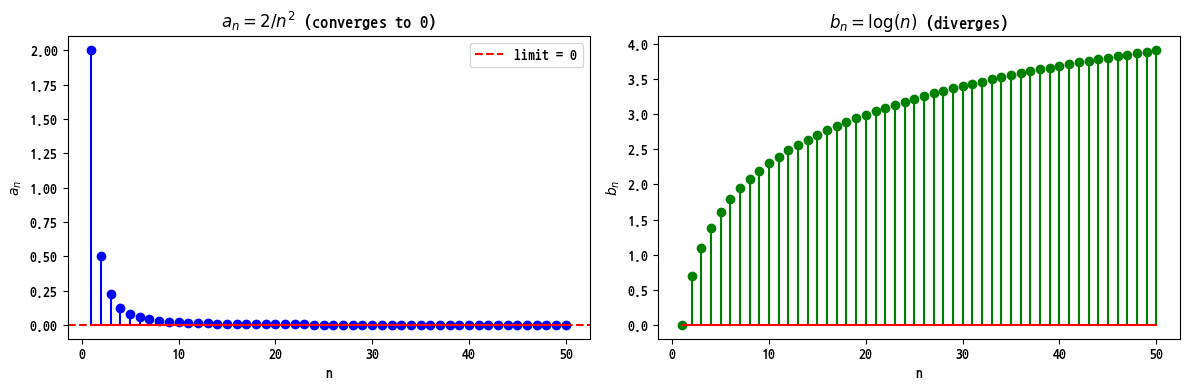

In [7]:
# a_n = 2/n^2 -> 0 (수렴)
# b_n = log(n)  -> inf (발산)

n = np.arange(1, 51)
a_n = 2 / n**2
b_n = np.log(n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(n, a_n, linefmt='b-', markerfmt='bo', basefmt='r-')
axes[0].axhline(y=0, color='r', linestyle='--', label='limit = 0')
axes[0].set_title(r'$a_n = 2/n^2$ (converges to 0)')
axes[0].set_xlabel('n')
axes[0].set_ylabel(r'$a_n$')
axes[0].legend()

axes[1].stem(n, b_n, linefmt='g-', markerfmt='go', basefmt='r-')
axes[1].set_title(r'$b_n = \log(n)$ (diverges)')
axes[1].set_xlabel('n')
axes[1].set_ylabel(r'$b_n$')

plt.tight_layout()
plt.show()

#### 예제: 등비수열의 극한 조사

1. $a_n = \frac{5^n}{3^n + 2}$ 의 수렴/발산
2. $b_n = \frac{3^{n+2} + 2 \cdot 5^{n+1}}{2^n + 5^n}$ 의 수렴/발산

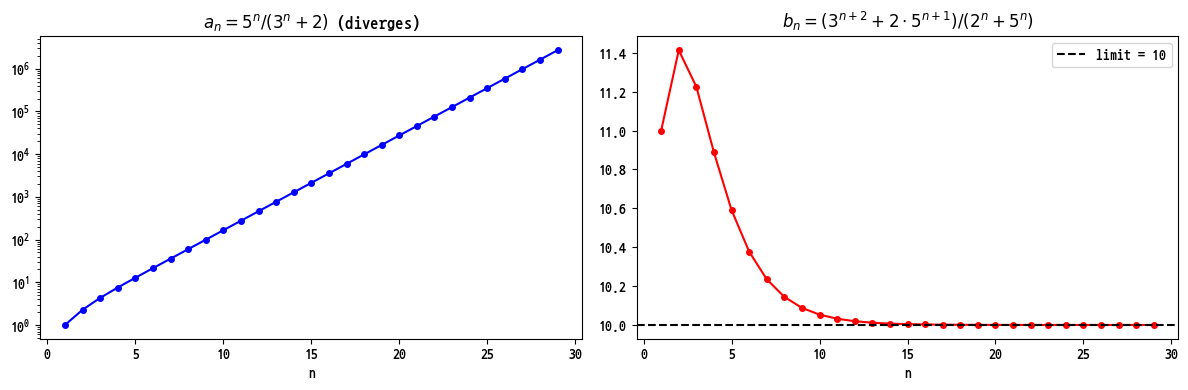

b_n at n=29: 10.0000033161 (limit = 10)


In [8]:
n = np.arange(1, 30)

# a_n = 5^n / (3^n + 2) => 분자/분모를 5^n으로 나누면 1/(3/5)^n + 2/5^n) -> inf (발산)
a_n = 5.0**n / (3.0**n + 2)

# b_n = (3^(n+2) + 2*5^(n+1)) / (2^n + 5^n)
# 분자/분모를 5^n으로 나누면 -> (9*(3/5)^n + 10) / ((2/5)^n + 1) -> 10
b_n = (3.0**(n+2) + 2 * 5.0**(n+1)) / (2.0**n + 5.0**n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n, a_n, 'bo-', markersize=4)
axes[0].set_title(r'$a_n = 5^n / (3^n + 2)$ (diverges)')
axes[0].set_xlabel('n')
axes[0].set_yscale('log')

axes[1].plot(n, b_n, 'ro-', markersize=4)
axes[1].axhline(y=10, color='k', linestyle='--', label='limit = 10')
axes[1].set_title(r'$b_n = (3^{n+2}+2\cdot5^{n+1})/(2^n+5^n)$')
axes[1].set_xlabel('n')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"b_n at n=29: {b_n[-1]:.10f} (limit = 10)")

### 1.3 급수 (Series)

급수 $\sum_{n=1}^{\infty} a_n$의 부분합 $S_n$이 수렴하면 급수가 수렴한다.

#### 예제: 등비급수의 수렴

$1 + \frac{1}{2} + \frac{1}{4} + \frac{1}{8} + \cdots = \frac{a}{1-r} = \frac{1}{1-1/2} = 2$

In [9]:
# 등비급수 합: a=1, r=1/2 -> 수렴값 = 2
sum1, n, diff = 0, 1, 1
while diff > 1e-6:
    sum0 = sum1 + (1/2)**(n-1)
    diff = abs(sum0 - sum1)
    n = n + 1
    sum1 = sum0

print(f"Geometric series sum = {sum0}")
print(f"Exact value = {1 / (1 - 0.5)}")
print(f"Number of terms needed: {n-1}")

Geometric series sum = 1.9999990463256836
Exact value = 2.0
Number of terms needed: 21


#### 예제: $\sum_{n=1}^{\infty} \frac{(-2)^n + 3^{n+1}}{5^n}$ 의 수렴

In [10]:
# 이 급수는 두 등비급수의 합으로 분리 가능
# sum (-2/5)^n + sum 3*(3/5)^n
# = (-2/5)/(1-(-2/5)) + 3*(3/5)/(1-3/5)
# = (-2/5)/(7/5) + (9/5)/(2/5)
# = -2/7 + 9/2 = -4/14 + 63/14 = 59/14

sum1, n, diff = 0, 1, 1
while diff > 1e-6:
    sum0 = sum1 + ((-2)**n + 3**(n+1)) / (5**n)
    diff = abs(sum0 - sum1)
    n = n + 1
    sum1 = sum0

print(f"Numerical sum  = {sum0:.10f}")
print(f"Exact: 59/14   = {59/14:.10f}")

Numerical sum  = 4.2142847195
Exact: 59/14   = 4.2142857143


### 1.4 오일러 넘버 (Euler Number)

$e = \lim_{n \to \infty} \left(1 + \frac{1}{n}\right)^n = \sum_{n=0}^{\infty} \frac{1}{n!}$

In [11]:
# 방법 1: (1 + 1/n)^n 으로 근사
ns = [10, 100, 1000, 10000, 100000, 1000000]
for n in ns:
    approx = (1 + 1/n)**n
    print(f"n = {n:>8d}: (1+1/n)^n = {approx:.10f}, error = {abs(approx - np.e):.2e}")

print(f"\nnp.e = {np.e:.10f}")

n =       10: (1+1/n)^n = 2.5937424601, error = 1.25e-01
n =      100: (1+1/n)^n = 2.7048138294, error = 1.35e-02
n =     1000: (1+1/n)^n = 2.7169239322, error = 1.36e-03
n =    10000: (1+1/n)^n = 2.7181459268, error = 1.36e-04
n =   100000: (1+1/n)^n = 2.7182682372, error = 1.36e-05
n =  1000000: (1+1/n)^n = 2.7182804691, error = 1.36e-06

np.e = 2.7182818285


In [13]:
# 방법 2: 급수 e = sum 1/n!
import scipy.special
e_approx = 0
for n in range(20):
    e_approx += 1 / scipy.special.factorial(n)

print(f"Series sum (20 terms) = {e_approx:.15f}")
print(f"np.e                  = {np.e:.15f}")
print(f"Error                 = {abs(e_approx - np.e):.2e}")

Series sum (20 terms) = 2.718281828459046
np.e                  = 2.718281828459045
Error                 = 4.44e-16


---
## II. 함수의 극한과 연속 (Limits and Continuity of Functions)

### 2.1 함수의 극한

SymPy를 사용하여 함수의 극한을 계산할 수 있다.

In [14]:
x = sym.symbols('x')

# 예제 1: lim_{x->0} |x|/x => 존재하지 않음 (좌극한 = -1, 우극한 = 1)
print("lim_{x->0+} |x|/x =", sym.limit(sym.Abs(x)/x, x, 0, '+'))
print("lim_{x->0-} |x|/x =", sym.limit(sym.Abs(x)/x, x, 0, '-'))
print("=> 좌극한 != 우극한이므로 극한이 존재하지 않음")

lim_{x->0+} |x|/x = 1
lim_{x->0-} |x|/x = -1
=> 좌극한 != 우극한이므로 극한이 존재하지 않음


In [15]:
# 예제 2: lim_{x->-5} (x^2 - 25)/(x + 5)
expr = (x**2 - 25) / (x + 5)
limit_val = sym.limit(expr, x, -5)
print(f"lim_{{x->-5}} (x^2 - 25)/(x + 5) = {limit_val}")
print(f"직접 인수분해: (x-5)(x+5)/(x+5) = x-5, x=-5 대입 => -10")

lim_{x->-5} (x^2 - 25)/(x + 5) = -10
직접 인수분해: (x-5)(x+5)/(x+5) = x-5, x=-5 대입 => -10


### 2.2 지수함수와 로그함수의 극한

In [16]:
x = sym.symbols('x')

# 예제 1: lim_{n->inf} (1 + 1/(2n))^{3n}
expr1 = (1 + 1/(2*x))**(3*x)
limit1 = sym.limit(expr1, x, sym.oo)
print("lim_{n->inf} (1 + 1/(2n))^{3n} =", limit1)

# 예제 2: lim_{x->0} log(1+x)/x
expr2 = sym.log(1 + x) / x
limit2 = sym.limit(expr2, x, 0)
print("lim_{x->0} log(1+x)/x =", limit2)

lim_{n->inf} (1 + 1/(2n))^{3n} = exp(3/2)
lim_{x->0} log(1+x)/x = 1


### 2.3 연속함수

함수 $f(x)$가 $x=a$에서 연속이려면:
1. $f(a)$ 정의됨
2. $\lim_{x \to a} f(x)$ 존재
3. $\lim_{x \to a} f(x) = f(a)$

In [17]:
# x=0에서 연속성 확인

# 1) f(x) = 3x^2 - 2x + 1: 다항함수 -> 연속
f = 3*x**2 - 2*x + 1
print("f(0) =", f.subs(x, 0))
print("lim f(x) as x->0 =", sym.limit(f, x, 0))
print("=> 연속 (f(0) = lim = 1)\n")

# 2) g(x) = |x|: 연속이지만 미분불가능
g = sym.Abs(x)
print("g(0) =", g.subs(x, 0))
print("lim g(x) as x->0 =", sym.limit(g, x, 0))
print("=> 연속\n")

# 3) h(x) = x/|x|: x=0에서 불연속
h = x / sym.Abs(x)
print("lim_{x->0+} h(x) =", sym.limit(h, x, 0, '+'))
print("lim_{x->0-} h(x) =", sym.limit(h, x, 0, '-'))
print("=> 좌극한 != 우극한, 불연속")

f(0) = 1
lim f(x) as x->0 = 1
=> 연속 (f(0) = lim = 1)

g(0) = 0
lim g(x) as x->0 = 0
=> 연속

lim_{x->0+} h(x) = 1
lim_{x->0-} h(x) = -1
=> 좌극한 != 우극한, 불연속


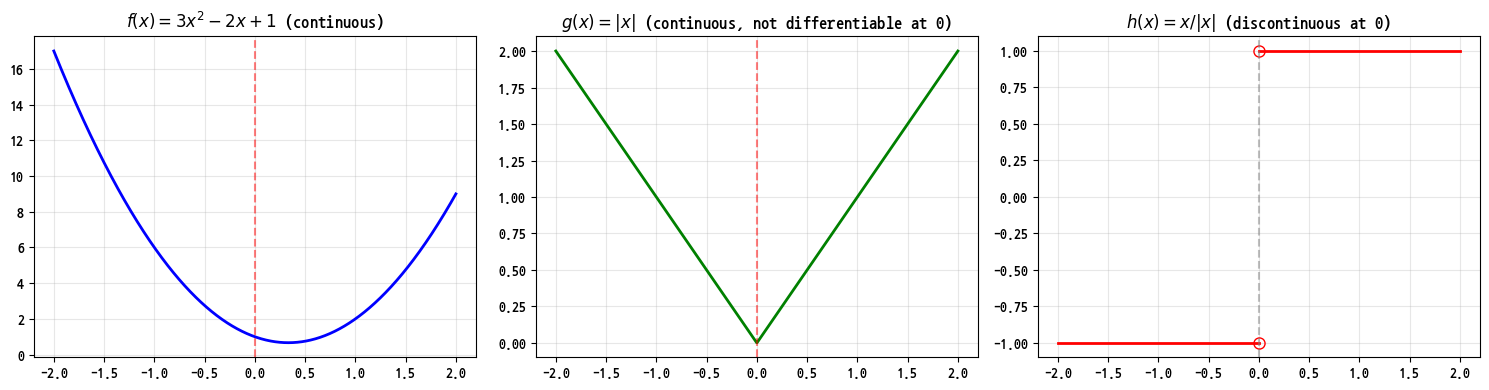

In [18]:
# 연속/불연속 함수 시각화
x_vals = np.linspace(-2, 2, 1000)
x_vals_no_zero = x_vals[x_vals != 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# f(x) = 3x^2 - 2x + 1
axes[0].plot(x_vals, 3*x_vals**2 - 2*x_vals + 1, 'b-', linewidth=2)
axes[0].set_title(r'$f(x) = 3x^2 - 2x + 1$ (continuous)')
axes[0].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# g(x) = |x|
axes[1].plot(x_vals, np.abs(x_vals), 'g-', linewidth=2)
axes[1].set_title(r'$g(x) = |x|$ (continuous, not differentiable at 0)')
axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

# h(x) = x/|x|
h_vals = np.sign(x_vals_no_zero)
axes[2].plot(x_vals_no_zero[x_vals_no_zero > 0], h_vals[x_vals_no_zero > 0], 'r-', linewidth=2)
axes[2].plot(x_vals_no_zero[x_vals_no_zero < 0], h_vals[x_vals_no_zero < 0], 'r-', linewidth=2)
axes[2].plot(0, 1, 'ro', markersize=8, fillstyle='none')  # open circle
axes[2].plot(0, -1, 'ro', markersize=8, fillstyle='none')
axes[2].set_title(r'$h(x) = x/|x|$ (discontinuous at 0)')
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4 중간값 정리 (Intermediate Value Theorem)

**예제**: $x^3 = x - 3$이 $(-2, 1)$에서 실근을 가짐을 확인하자.

f(-2) = -3
f(1)  = 3

f(-2) = -3 < 0
f(1)  = 3 > 0
=> f(-2) < 0 < f(1)이므로 중간값 정리에 의해 (-2,1)에서 실근 존재


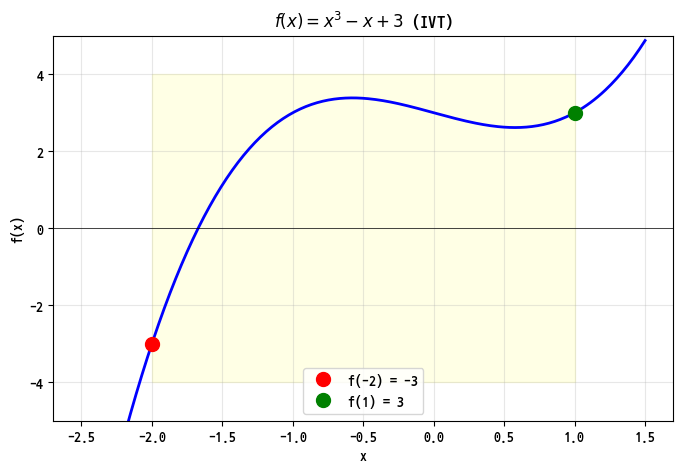

In [19]:
# f(x) = x^3 - x + 3
f_ivt = lambda x: x**3 - x + 3

print(f"f(-2) = {f_ivt(-2)}")  # -2 + 2 + 3 = -8+2+3 = -3
print(f"f(1)  = {f_ivt(1)}")   # 1-1+3 = 3
# 부호가 다르지 않으므로 (-2,1)에서 근이 없을 수도 있음
# 원래 문제: x^3 - x + 3 = 0
# f(-2)=-3 < 0, f(1)=3 > 0 => 부호가 다름 => 근이 존재

print(f"\nf(-2) = {f_ivt(-2)} < 0")
print(f"f(1)  = {f_ivt(1)} > 0")
print("=> f(-2) < 0 < f(1)이므로 중간값 정리에 의해 (-2,1)에서 실근 존재")

# 시각화
x_vals = np.linspace(-2.5, 1.5, 300)
plt.figure(figsize=(8, 5))
plt.plot(x_vals, f_ivt(x_vals), 'b-', linewidth=2)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.plot(-2, f_ivt(-2), 'ro', markersize=10, label=f'f(-2) = {f_ivt(-2)}')
plt.plot(1, f_ivt(1), 'go', markersize=10, label=f'f(1) = {f_ivt(1)}')
plt.fill_betweenx([-4, 4], -2, 1, alpha=0.1, color='yellow')
plt.title(r'$f(x) = x^3 - x + 3$ (IVT)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-5, 5)
plt.show()

---
## III. 미분 (Differentiation)

### 3.1 미분계수와 도함수

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

In [20]:
# 수치적 미분 (numerical differentiation)
def numerical_derivative(f, x, h=1e-7):
    """중심차분법(central difference)으로 수치 미분"""
    return (f(x + h) - f(x - h)) / (2 * h)

# 예제: f(x) = x^3 at x=2
f = lambda x: x**3
print(f"f'(2) numerical  = {numerical_derivative(f, 2):.10f}")
print(f"f'(2) analytical = {3 * 2**2}  (since f'(x) = 3x^2)")

f'(2) numerical  = 11.9999999937
f'(2) analytical = 12  (since f'(x) = 3x^2)


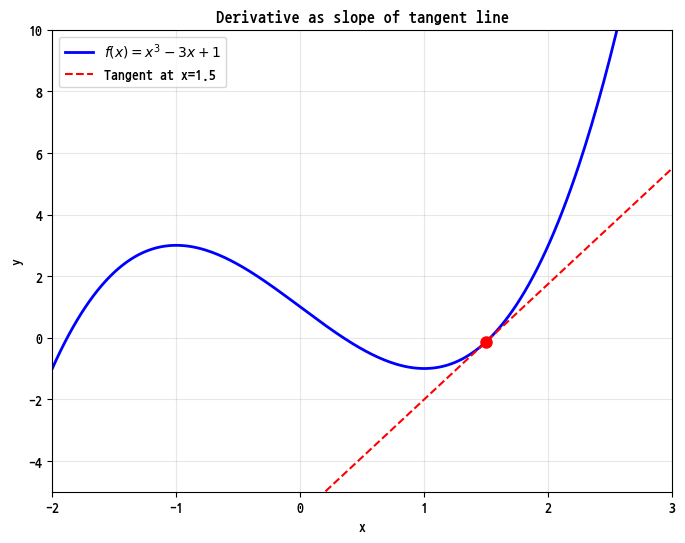

f'(1.5) = 3.75


In [21]:
# 미분계수의 기하학적 의미: 접선의 기울기
f = lambda x: x**3 - 3*x + 1
f_prime = lambda x: 3*x**2 - 3

a = 1.5  # 접점
slope = f_prime(a)

x_vals = np.linspace(-2, 3, 300)
tangent = f(a) + slope * (x_vals - a)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, f(x_vals), 'b-', linewidth=2, label=r'$f(x) = x^3 - 3x + 1$')
plt.plot(x_vals, tangent, 'r--', linewidth=1.5, label=f'Tangent at x={a}')
plt.plot(a, f(a), 'ro', markersize=8)
plt.xlim(-2, 3)
plt.ylim(-5, 10)
plt.title('Derivative as slope of tangent line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"f'({a}) = {slope}")

### 3.2 SymPy를 이용한 미분

`sym.diff(f, x)`를 사용하면 기호적(symbolic) 미분이 가능하다.

In [22]:
x = sym.Symbol('x')

# 기본 미분 공식들
functions = {
    'x^n (n=5)': x**5,
    'e^x': sym.exp(x),
    'log(x)': sym.log(x),
    'sin(x)': sym.sin(x),
    'cos(x)': sym.cos(x),
    'tan(x)': sym.tan(x),
    'a^x (a=2)': 2**x,
}

print(f"{'Function':>15s} | {'Derivative':>30s}")
print('-' * 50)
for name, func in functions.items():
    deriv = sym.simplify(sym.diff(func, x))
    print(f"{name:>15s} | {str(deriv):>30s}")

       Function |                     Derivative
--------------------------------------------------
      x^n (n=5) |                         5*x**4
            e^x |                         exp(x)
         log(x) |                            1/x
         sin(x) |                         cos(x)
         cos(x) |                        -sin(x)
         tan(x) |                   cos(x)**(-2)
      a^x (a=2) |                    2**x*log(2)


### 3.3 미분 공식 (Differentiation Rules)

In [23]:
x = sym.Symbol('x')

# 연습문제 1: f(x) = e^x / x
fx = sym.exp(x) / x
fx_prime = sym.simplify(sym.diff(fx, x))
print("1) d/dx [e^x / x] =", fx_prime)

# 연습문제 2: g(x) = 3*log_2(x) - x*log(x)
gx = 3 * sym.log(x, 2) - x * sym.log(x)
gx_prime = sym.simplify(sym.diff(gx, x))
print("\n2) d/dx [3*log2(x) - x*log(x)] =", gx_prime)

# 연습문제 3: h(x) = 2cos(x) - tan(x)
hx = 2 * sym.cos(x) - sym.tan(x)
hx_prime = sym.simplify(sym.diff(hx, x))
print("\n3) d/dx [2cos(x) - tan(x)] =", hx_prime)

# 연습문제 4: z(x) = e^x * log(x)
zx = sym.exp(x) * sym.log(x)
zx_prime = sym.simplify(sym.diff(zx, x))
print("\n4) d/dx [e^x * log(x)] =", zx_prime)

1) d/dx [e^x / x] = (x - 1)*exp(x)/x**2

2) d/dx [3*log2(x) - x*log(x)] = -log(x) - 1 + 3/(x*log(2))

3) d/dx [2cos(x) - tan(x)] = -2*sin(x) - 1/cos(x)**2

4) d/dx [e^x * log(x)] = (x*log(x) + 1)*exp(x)/x


### 3.4 연쇄법칙 (Chain Rule)

$$\frac{df}{dx} = \frac{dh}{dg} \times \frac{dg}{dx}$$

In [24]:
x = sym.Symbol('x')
mu, sigma = sym.symbols('mu sigma', positive=True)

# 예제 1: f(x) = exp(-(x-mu)^2 / (2*sigma^2))
fx = sym.exp(-(x - mu)**2 / (2 * sigma**2))
fx_prime = sym.simplify(sym.diff(fx, x))
print("1) d/dx exp(-(x-mu)^2/(2*sigma^2)) =")
print("  ", fx_prime)

# 예제 2: d/dx log(f(x)) = f'(x)/f(x)
f = sym.Function('f')
result = sym.diff(sym.log(f(x)), x)
print("\n2) d/dx log(f(x)) =", result)

1) d/dx exp(-(x-mu)^2/(2*sigma^2)) =
   (mu - x)*exp(-(mu - x)**2/(2*sigma**2))/sigma**2

2) d/dx log(f(x)) = Derivative(f(x), x)/f(x)


In [25]:
x = sym.Symbol('x')

# 연쇄법칙 연습
print("=== Chain Rule Examples ===")

# 1) f(x) = (x^2 + 2)^3
fx = (x**2 + 2)**3
print("\n1) d/dx (x^2+2)^3 =", sym.simplify(sym.diff(fx, x)))

# 2) g(x) = 1/(x^4+1)^2
gx = 1 / (x**4 + 1)**2
print("\n2) d/dx 1/(x^4+1)^2 =", sym.simplify(sym.diff(gx, x)))

# 3) h(x) = log(x^2 + 4)
hx = sym.log(x**2 + 4)
print("\n3) d/dx log(x^2+4) =", sym.simplify(sym.diff(hx, x)))

# 4) z(x) = sin(tan(x))
zx = sym.sin(sym.tan(x))
print("\n4) d/dx sin(tan(x)) =", sym.simplify(sym.diff(zx, x)))

=== Chain Rule Examples ===

1) d/dx (x^2+2)^3 = 6*x*(x**2 + 2)**2

2) d/dx 1/(x^4+1)^2 = -8*x**3/(x**4 + 1)**3

3) d/dx log(x^2+4) = 2*x/(x**2 + 4)

4) d/dx sin(tan(x)) = cos(tan(x))/cos(x)**2


### 3.5 고차도함수 (Higher-order Derivatives)

In [26]:
x = sym.Symbol('x')

# f(x) = e^x의 n차 도함수 (자기 자신)
f = sym.exp(x)
for n in range(1, 5):
    print(f"d^{n}/dx^{n} [e^x] = {sym.diff(f, x, n)}")

print()

# g(x) = x^5의 n차 도함수
g = x**5
for n in range(1, 7):
    print(f"d^{n}/dx^{n} [x^5] = {sym.diff(g, x, n)}")

d^1/dx^1 [e^x] = exp(x)
d^2/dx^2 [e^x] = exp(x)
d^3/dx^3 [e^x] = exp(x)
d^4/dx^4 [e^x] = exp(x)

d^1/dx^1 [x^5] = 5*x**4
d^2/dx^2 [x^5] = 20*x**3
d^3/dx^3 [x^5] = 60*x**2
d^4/dx^4 [x^5] = 120*x
d^5/dx^5 [x^5] = 120
d^6/dx^6 [x^5] = 0


### 3.6 테일러 전개 (Taylor Expansion)

$$f(x) \approx \sum_{p=0}^{n} \frac{f^{(p)}(a)}{p!}(x-a)^p$$

In [27]:
x = sym.Symbol('x')

# exp(x)의 x=0에서의 테일러 전개
print("=== Taylor series of e^x around x=0 ===")
for order in [1, 2, 3, 5, 10]:
    taylor = sym.series(sym.exp(x), x, 0, order + 1).removeO()
    print(f"Order {order:>2d}: {taylor}")

=== Taylor series of e^x around x=0 ===
Order  1: x + 1
Order  2: x**2/2 + x + 1
Order  3: x**3/6 + x**2/2 + x + 1
Order  5: x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1
Order 10: x**10/3628800 + x**9/362880 + x**8/40320 + x**7/5040 + x**6/720 + x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1


In [28]:
# 주요 함수의 테일러 급수
print("=== Taylor series of common functions (around x=0) ===")

funcs = {
    'exp(x)': sym.exp(x),
    'log(1+x)': sym.log(1 + x),
    'sin(x)': sym.sin(x),
    'cos(x)': sym.cos(x),
    '1/(1-x)': 1 / (1 - x),
}

for name, func in funcs.items():
    taylor = sym.series(func, x, 0, 6)
    print(f"{name:>10s}: {taylor}")

=== Taylor series of common functions (around x=0) ===
    exp(x): 1 + x + x**2/2 + x**3/6 + x**4/24 + x**5/120 + O(x**6)
  log(1+x): x - x**2/2 + x**3/3 - x**4/4 + x**5/5 + O(x**6)
    sin(x): x - x**3/6 + x**5/120 + O(x**6)
    cos(x): 1 - x**2/2 + x**4/24 + O(x**6)
   1/(1-x): 1 + x + x**2 + x**3 + x**4 + x**5 + O(x**6)


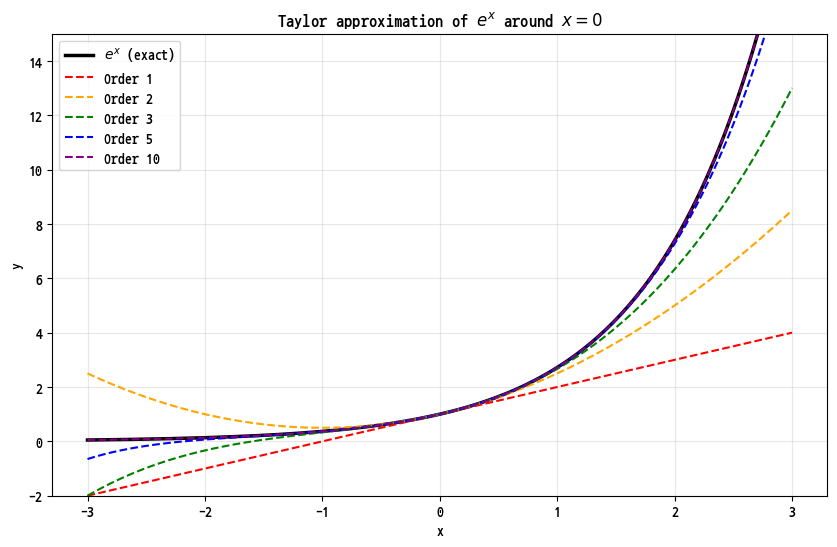

In [30]:
# 테일러 근사 시각화: exp(x)
x_vals = np.linspace(-3, 3, 300)
y_exact = np.exp(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_exact, 'k-', linewidth=2.5, label=r'$e^x$ (exact)')

colors = ['red', 'orange', 'green', 'blue', 'purple']
for i, order in enumerate([1, 2, 3, 5, 10]):
    y_approx = np.zeros_like(x_vals)
    for k in range(order + 1):
        y_approx += x_vals**k / scipy.special.factorial(k)
    plt.plot(x_vals, y_approx, color=colors[i], linestyle='--', 
             linewidth=1.5, label=f'Order {order}')

plt.ylim(-2, 15)
plt.title(r'Taylor approximation of $e^x$ around $x=0$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

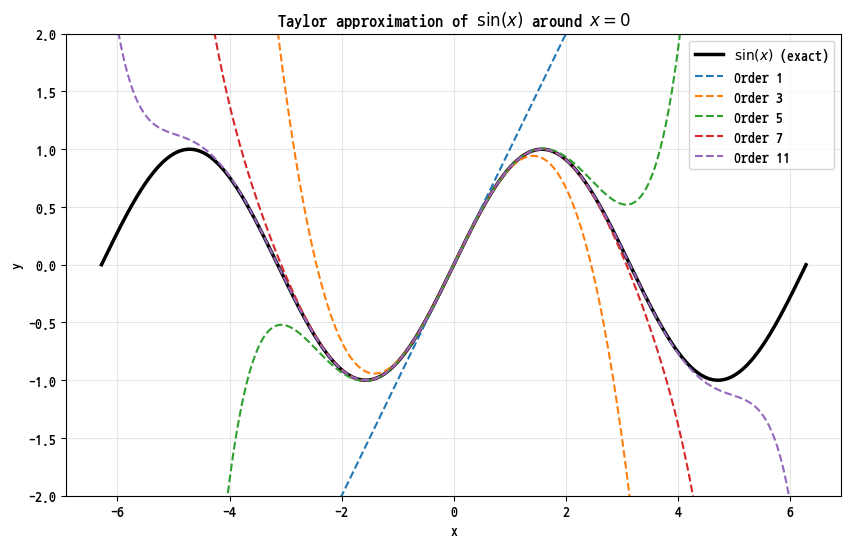

In [32]:
# 테일러 근사 시각화: sin(x)
x_vals = np.linspace(-2*np.pi, 2*np.pi, 500)
y_exact = np.sin(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_exact, 'k-', linewidth=2.5, label=r'$\sin(x)$ (exact)')

for i, order in enumerate([1, 3, 5, 7, 11]):
    y_approx = np.zeros_like(x_vals)
    for k in range(order + 1):
        coeff = sym.diff(sym.sin(sym.Symbol('x')), sym.Symbol('x'), k).subs(sym.Symbol('x'), 0)
        y_approx += float(coeff) / scipy.special.factorial(k) * x_vals**k
    plt.plot(x_vals, y_approx, linestyle='--', linewidth=1.5, label=f'Order {order}')

plt.ylim(-2, 2)
plt.title(r'Taylor approximation of $\sin(x)$ around $x=0$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.7 로피탈의 정리 (L'Hôpital's Rule)

$\frac{0}{0}$ 또는 $\frac{\infty}{\infty}$ 꼴에서:
$$\lim_{x \to a} \frac{f(x)}{g(x)} = \lim_{x \to a} \frac{f'(x)}{g'(x)}$$

In [33]:
x = sym.Symbol('x')

# 예제 1: lim_{x->0} (x - x^3/6) / sin(x)
expr1 = (x - x**3/6) / sym.sin(x)
print("1) lim_{x->0} (x - x^3/6)/sin(x) =", sym.limit(expr1, x, 0))

# 수동으로 로피탈 적용
num1 = x - x**3/6
den1 = sym.sin(x)
# f'(x)/g'(x)
ratio = sym.diff(num1, x) / sym.diff(den1, x)
print("   L'Hospital: lim f'/g' =", sym.limit(ratio, x, 0))

print()

# 예제 2: lim_{x->inf} log(x)/x^2
expr2 = sym.log(x) / x**2
print("2) lim_{x->inf} log(x)/x^2 =", sym.limit(expr2, x, sym.oo))

# L'Hospital: (1/x) / (2x) = 1/(2x^2) -> 0
num2 = sym.log(x)
den2 = x**2
ratio2 = sym.diff(num2, x) / sym.diff(den2, x)
print("   L'Hospital: lim f'/g' =", sym.limit(ratio2, x, sym.oo))

1) lim_{x->0} (x - x^3/6)/sin(x) = 1
   L'Hospital: lim f'/g' = 1

2) lim_{x->inf} log(x)/x^2 = 0
   L'Hospital: lim f'/g' = 0


### 3.8 함수의 극대, 극소, 볼록성

In [34]:
x = sym.Symbol('x')

# f(x) = 2x^3 - 9x^2 + 12x + 4
f = 2*x**3 - 9*x**2 + 12*x + 4
f_prime = sym.diff(f, x)
f_double_prime = sym.diff(f, x, 2)

print("f(x)   =", f)
print("f'(x)  =", f_prime)
print("f''(x) =", f_double_prime)

# 극점 찾기: f'(x) = 0
critical_pts = sym.solve(f_prime, x)
print("\nCritical points (f'=0):", critical_pts)

for pt in critical_pts:
    f2_val = f_double_prime.subs(x, pt)
    f_val = f.subs(x, pt)
    if f2_val > 0:
        print(f"  x={pt}: f''={f2_val} > 0 => local minimum, f({pt})={f_val}")
    elif f2_val < 0:
        print(f"  x={pt}: f''={f2_val} < 0 => local maximum, f({pt})={f_val}")
    else:
        print(f"  x={pt}: f''={f2_val} = 0 => inconclusive")

# 변곡점: f''(x) = 0
inflection_pts = sym.solve(f_double_prime, x)
print("\nInflection points (f''=0):", inflection_pts)

f(x)   = 2*x**3 - 9*x**2 + 12*x + 4
f'(x)  = 6*x**2 - 18*x + 12
f''(x) = 6*(2*x - 3)

Critical points (f'=0): [1, 2]
  x=1: f''=-6 < 0 => local maximum, f(1)=9
  x=2: f''=6 > 0 => local minimum, f(2)=8

Inflection points (f''=0): [3/2]


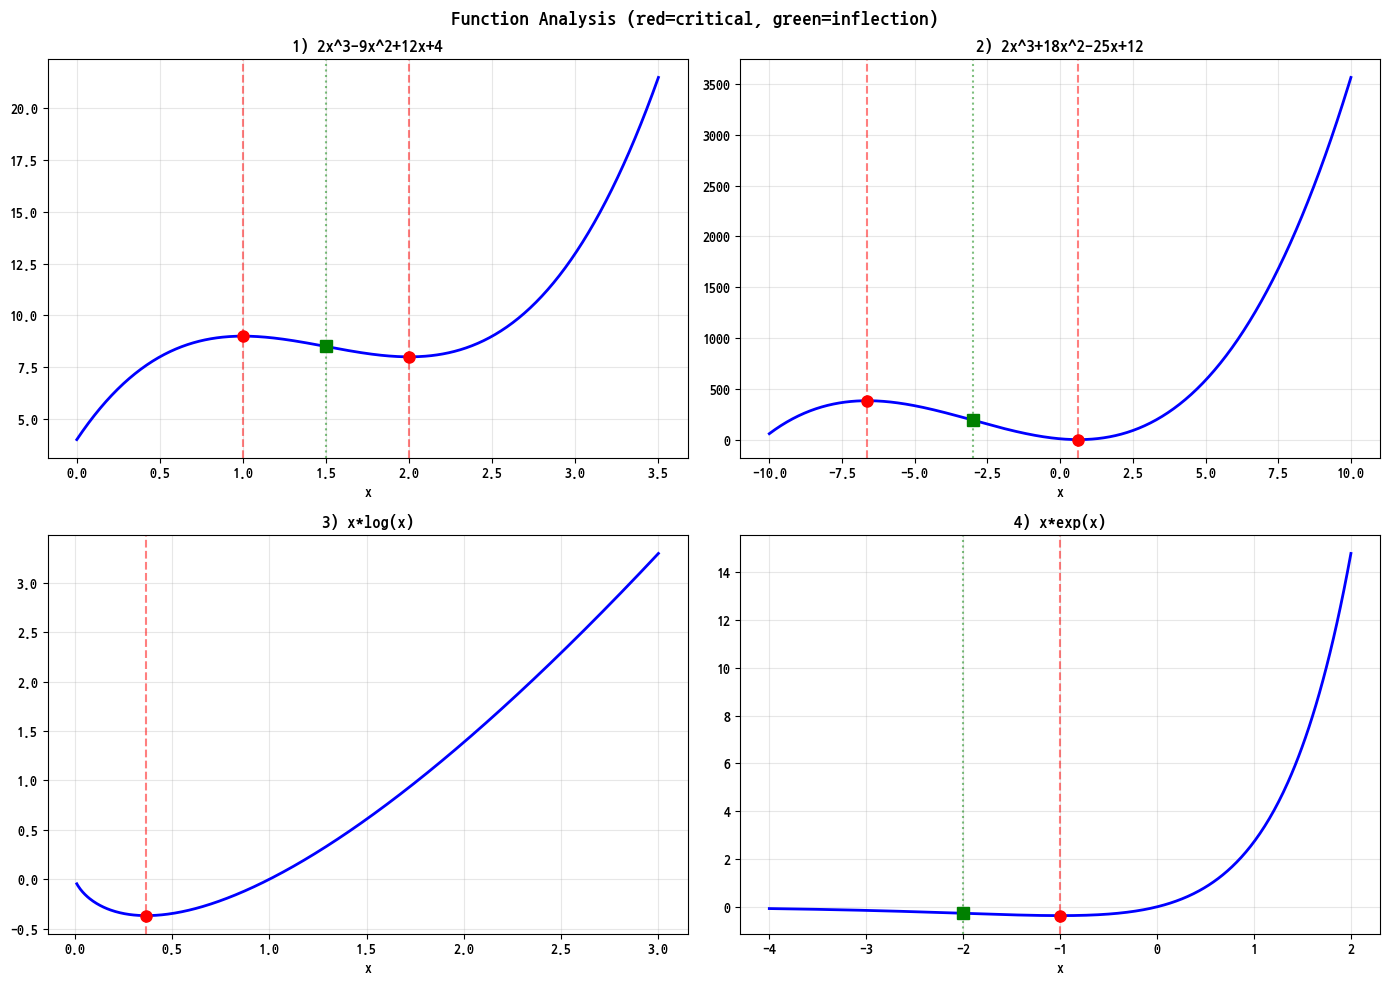

In [35]:
# 4개 함수의 그래프 분석
x_sym = sym.Symbol('x')

functions = {
    '1) 2x^3-9x^2+12x+4': (2*x_sym**3 - 9*x_sym**2 + 12*x_sym + 4, (0, 3.5)),
    '2) 2x^3+18x^2-25x+12': (2*x_sym**3 + 18*x_sym**2 - 25*x_sym + 12, (-10, 10)),
    '3) x*log(x)': (x_sym * sym.log(x_sym), (0.01, 3)),
    '4) x*exp(x)': (x_sym * sym.exp(x_sym), (-4, 2)),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, (func, xlim)) in enumerate(functions.items()):
    f_np = sym.lambdify(x_sym, func, 'numpy')
    xv = np.linspace(xlim[0], xlim[1], 500)
    yv = f_np(xv)
    
    # 유한한 값만 플롯
    mask = np.isfinite(yv)
    
    ax = axes[idx]
    ax.plot(xv[mask], yv[mask], 'b-', linewidth=2)
    
    # 극점 표시
    fp = sym.diff(func, x_sym)
    try:
        cps = sym.solve(fp, x_sym)
        for cp in cps:
            cp_f = float(cp)
            if xlim[0] <= cp_f <= xlim[1]:
                yp = float(func.subs(x_sym, cp))
                if np.isfinite(yp):
                    ax.plot(cp_f, yp, 'ro', markersize=8)
                    ax.axvline(x=cp_f, color='r', linestyle='--', alpha=0.5)
    except:
        pass
    
    # 변곡점 표시
    fpp = sym.diff(func, x_sym, 2)
    try:
        ips = sym.solve(fpp, x_sym)
        for ip in ips:
            ip_f = float(ip)
            if xlim[0] <= ip_f <= xlim[1]:
                yip = float(func.subs(x_sym, ip))
                if np.isfinite(yip):
                    ax.plot(ip_f, yip, 'gs', markersize=8)
                    ax.axvline(x=ip_f, color='g', linestyle=':', alpha=0.5)
    except:
        pass
    
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')

plt.suptitle('Function Analysis (red=critical, green=inflection)', fontsize=14)
plt.tight_layout()
plt.show()

### 3.9 응용: 최대가능도 추정 (Maximum Likelihood Estimation)

이항 표본에서 로그 가능도:
$$\ell(\theta) = s \log \theta + (n-s) \log(1-\theta)$$

MLE: $\hat{\theta} = s/n = \bar{x}$

MLE: theta_hat = [7/20]
     = 7/20 = 0.35
l''(theta_hat) = -8000/91 < 0 => maximum


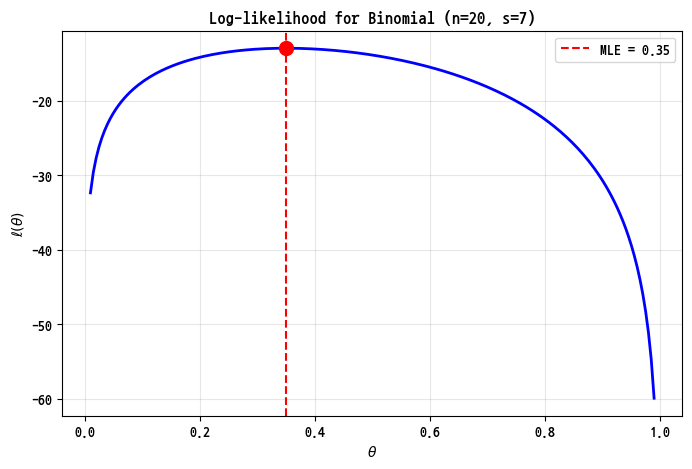

In [36]:
# 이항분포 MLE 시각화
theta = sym.Symbol('theta')

# 예시 데이터: n=20, s=7
n_obs = 20
s_obs = 7

# 로그 가능도
log_lik = s_obs * sym.log(theta) + (n_obs - s_obs) * sym.log(1 - theta)
log_lik_prime = sym.diff(log_lik, theta)
log_lik_double = sym.diff(log_lik, theta, 2)

# MLE
theta_hat = sym.solve(log_lik_prime, theta)
print(f"MLE: theta_hat = {theta_hat}")
print(f"     = {s_obs}/{n_obs} = {s_obs/n_obs}")

# 2차 도함수 확인
print(f"l''(theta_hat) = {log_lik_double.subs(theta, sym.Rational(s_obs, n_obs))} < 0 => maximum")

# 시각화
theta_vals = np.linspace(0.01, 0.99, 200)
ll_vals = s_obs * np.log(theta_vals) + (n_obs - s_obs) * np.log(1 - theta_vals)

plt.figure(figsize=(8, 5))
plt.plot(theta_vals, ll_vals, 'b-', linewidth=2)
plt.axvline(x=s_obs/n_obs, color='r', linestyle='--', label=f'MLE = {s_obs/n_obs}')
plt.plot(s_obs/n_obs, s_obs*np.log(s_obs/n_obs) + (n_obs-s_obs)*np.log(1-s_obs/n_obs), 
         'ro', markersize=10)
plt.title(f'Log-likelihood for Binomial (n={n_obs}, s={s_obs})')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\ell(\theta)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## IV. 편미분 (Partial Derivatives)

### 4.1 편도함수 계산

In [37]:
x, y = sym.symbols('x y')

# 예제 1: f(x,y) = (1/2pi) * exp(-(x^2+y^2)/2)
f = (1 / (2 * sym.pi)) * sym.exp(-(x**2 + y**2) / 2)

fx = sym.diff(f, x)
fy = sym.diff(f, y)

print("f(x,y) = (1/2pi) * exp(-(x^2+y^2)/2)")
print("\ndf/dx =", fx)
print("df/dy =", fy)

# P: (1, 0)에서의 값
print("\nAt P=(1,0):")
print("  df/dx|(1,0) =", fx.subs([(x, 1), (y, 0)]))
print("  df/dy|(1,0) =", fy.subs([(x, 1), (y, 0)]))

f(x,y) = (1/2pi) * exp(-(x^2+y^2)/2)

df/dx = -x*exp(-x**2/2 - y**2/2)/(2*pi)
df/dy = -y*exp(-x**2/2 - y**2/2)/(2*pi)

At P=(1,0):
  df/dx|(1,0) = -exp(-1/2)/(2*pi)
  df/dy|(1,0) = 0


In [38]:
# 예제 2: f(x,y) = x^2 + 4xy + 4y^2
f2 = x**2 + 4*x*y + 4*y**2

f2x = sym.diff(f2, x)
f2y = sym.diff(f2, y)

print("f(x,y) = x^2 + 4xy + 4y^2")
print("df/dx =", f2x)
print("df/dy =", f2y)

f(x,y) = x^2 + 4xy + 4y^2
df/dx = 2*x + 4*y
df/dy = 4*x + 8*y


### 4.2 2차 편미분

In [39]:
x, y = sym.symbols('x y')
f = (1 / (2 * sym.pi)) * sym.exp(-(x**2 + y**2) / 2)

fx = sym.diff(f, x)
fy = sym.diff(f, y)

fxx = sym.diff(fx, x)
fyy = sym.diff(fy, y)
fxy = sym.diff(fx, y)
fyx = sym.diff(fy, x)

print("2nd order partial derivatives:")
print("fxx =", sym.simplify(fxx))
print("fyy =", sym.simplify(fyy))
print("fxy =", sym.simplify(fxy))
print("fyx =", sym.simplify(fyx))
print("\nfxy == fyx?", sym.simplify(fxy - fyx) == 0)

print("\nAt P=(1,0):")
print("  fxx|(1,0) =", fxx.subs([(x, 1), (y, 0)]))
print("  fyy|(1,0) =", fyy.subs([(x, 1), (y, 0)]))
print("  fxy|(1,0) =", fxy.subs([(x, 1), (y, 0)]))

print("\nAt Q=(0,0):")
print("  fxx|(0,0) =", fxx.subs([(x, 0), (y, 0)]))
print("  fyy|(0,0) =", fyy.subs([(x, 0), (y, 0)]))
print("  fxy|(0,0) =", fxy.subs([(x, 0), (y, 0)]))

2nd order partial derivatives:
fxx = (x**2 - 1)*exp(-x**2/2 - y**2/2)/(2*pi)
fyy = (y**2 - 1)*exp(-x**2/2 - y**2/2)/(2*pi)
fxy = x*y*exp(-x**2/2 - y**2/2)/(2*pi)
fyx = x*y*exp(-x**2/2 - y**2/2)/(2*pi)

fxy == fyx? True

At P=(1,0):
  fxx|(1,0) = 0
  fyy|(1,0) = -exp(-1/2)/(2*pi)
  fxy|(1,0) = 0

At Q=(0,0):
  fxx|(0,0) = -1/(2*pi)
  fyy|(0,0) = -1/(2*pi)
  fxy|(0,0) = 0


### 4.3 이변수 함수의 극대/극소 (2계 도함수 테스트)

In [41]:
x, y = sym.symbols('x y')

def analyze_critical_points(f_expr, name=""):
    """이변수 함수의 극점 분석"""
    print(f"\n{'='*50}")
    print(f"f(x,y) = {f_expr}")
    
    fx = sym.diff(f_expr, x)
    fy = sym.diff(f_expr, y)
    fxx = sym.diff(f_expr, x, 2)
    fyy = sym.diff(f_expr, y, 2)
    fxy = sym.diff(f_expr, x, y)
    
    print(f"fx = {fx}")
    print(f"fy = {fy}")
    
    # 극점 찾기
    cps = sym.solve([fx, fy], [x, y])
    print(f"Critical points: {cps}")
    
    if isinstance(cps, dict):
        cps = [(cps[x], cps[y])]
    
    for pt in cps:
        x0, y0 = pt
        D = (fxx * fyy - fxy**2).subs([(x, x0), (y, y0)])
        fxx_val = fxx.subs([(x, x0), (y, y0)])
        f_val = f_expr.subs([(x, x0), (y, y0)])
        
        print(f"\n  At ({x0}, {y0}):")
        print(f"    D = fxx*fyy - fxy^2 = {D}")
        print(f"    fxx = {fxx_val}")
        
        if D > 0 and fxx_val > 0:
            print(f"    => Local MINIMUM, f = {f_val}")
        elif D > 0 and fxx_val < 0:
            print(f"    => Local MAXIMUM, f = {f_val}")
        elif D < 0:
            print(f"    => SADDLE POINT, f = {f_val}")
        else:
            print(f"    => Inconclusive (D=0)")

# 예제들
analyze_critical_points(x**2 + y**2 + x*y)
analyze_critical_points(x**2 - y**2)


f(x,y) = x**2 + x*y + y**2
fx = 2*x + y
fy = x + 2*y
Critical points: {x: 0, y: 0}

  At (0, 0):
    D = fxx*fyy - fxy^2 = 3
    fxx = 2
    => Local MINIMUM, f = 0

f(x,y) = x**2 - y**2
fx = 2*x
fy = -2*y
Critical points: {x: 0, y: 0}

  At (0, 0):
    D = fxx*fyy - fxy^2 = -4
    fxx = 2
    => SADDLE POINT, f = 0


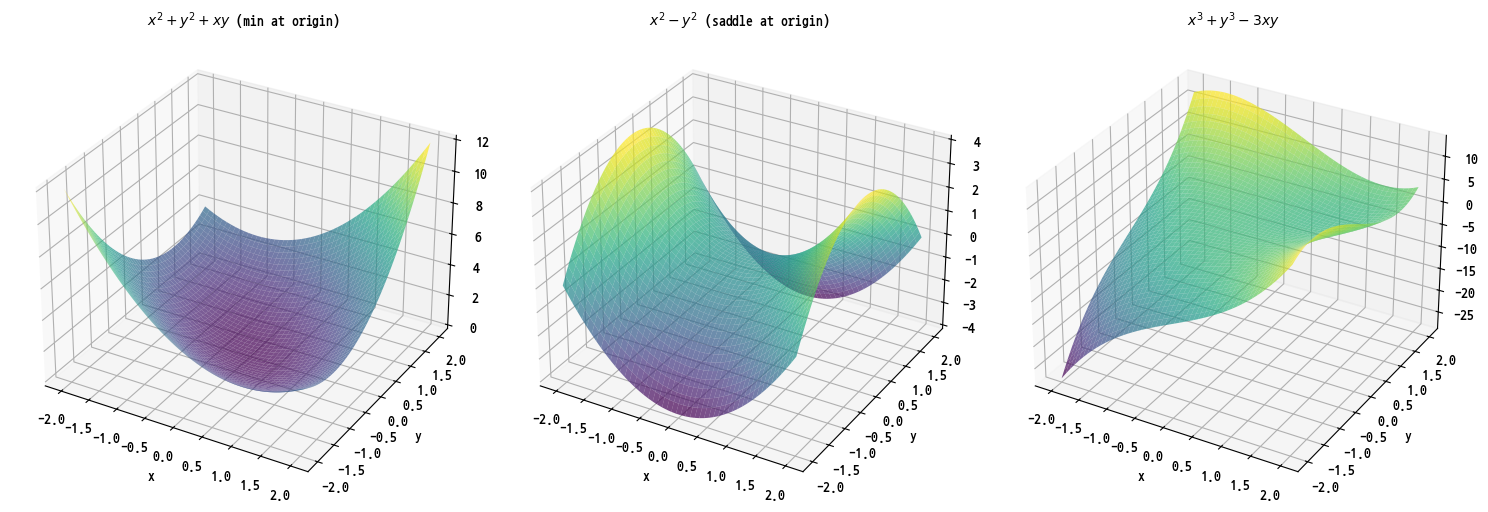

In [42]:
# 3D 시각화: f(x,y) = x^2 + y^2 + xy (극소점)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 5))

funcs_3d = [
    (r'$x^2 + y^2 + xy$ (min at origin)', lambda x, y: x**2 + y**2 + x*y),
    (r'$x^2 - y^2$ (saddle at origin)', lambda x, y: x**2 - y**2),
    (r'$x^3 + y^3 - 3xy$', lambda x, y: x**3 + y**3 - 3*x*y),
]

for idx, (title, func) in enumerate(funcs_3d):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    X = np.linspace(-2, 2, 50)
    Y = np.linspace(-2, 2, 50)
    X, Y = np.meshgrid(X, Y)
    Z = func(X, Y)
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

### 4.4 기울기 벡터 (Gradient)와 라그랑지 승수법

In [43]:
# 라그랑지 승수법
# 예제 1: minimize x^2 + 2y^2 subject to x + y = 1
x, y, lam = sym.symbols('x y lambda')

f = x**2 + 2*y**2
g = x + y - 1  # constraint: g = 0

# Lagrangian: L = f - lambda * g
L = f - lam * g

# dL/dx = 0, dL/dy = 0, dL/dlambda = 0
eq1 = sym.diff(L, x)
eq2 = sym.diff(L, y)
eq3 = sym.diff(L, lam)

solution = sym.solve([eq1, eq2, eq3], [x, y, lam])
print("Lagrange multiplier method:")
print(f"  Minimize: f = x^2 + 2y^2")
print(f"  Subject to: x + y = 1")
print(f"  Solution: {solution}")
x_opt, y_opt = solution[x], solution[y]
print(f"  Minimum value: f({x_opt}, {y_opt}) = {f.subs([(x, x_opt), (y, y_opt)])}")

Lagrange multiplier method:
  Minimize: f = x^2 + 2y^2
  Subject to: x + y = 1
  Solution: {lambda: 4/3, x: 2/3, y: 1/3}
  Minimum value: f(2/3, 1/3) = 2/3


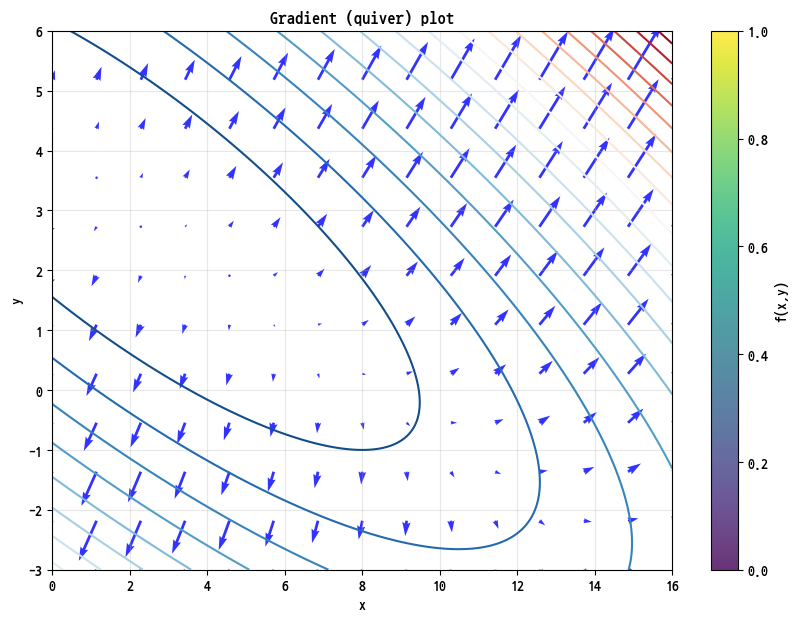

In [44]:
# 기울기 벡터(Gradient) 시각화 - Quiver plot
f_func = lambda x, y: 2*x**2 + 6*x*y + 7*y**2 - 26*x - 54*y + 107
grad_x = lambda x, y: 4*x + 6*y - 26
grad_y = lambda x, y: 6*x + 14*y - 54

X = np.linspace(0, 16, 15)
Y = np.linspace(-3, 6, 12)
Xg, Yg = np.meshgrid(X, Y)
U = grad_x(Xg, Yg)
V = grad_y(Xg, Yg)

# Contour plot
Xc = np.linspace(0, 16, 200)
Yc = np.linspace(-3, 6, 200)
Xc, Yc = np.meshgrid(Xc, Yc)
Zc = f_func(Xc, Yc)

plt.figure(figsize=(10, 7))
plt.contour(Xc, Yc, Zc, levels=20, cmap='RdBu_r')
plt.quiver(Xg, Yg, U, V, color='blue', alpha=0.8)
plt.colorbar(label='f(x,y)')
plt.title('Gradient (quiver) plot')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

### 4.5 연쇄법칙 (편미분)

In [45]:
# z = x^3 * y^2, x=t, y=t^2
# dz/dt = dz/dx * dx/dt + dz/dy * dy/dt

x, y, t = sym.symbols('x y t')

z = x**3 * y**2
x_t = t
y_t = t**2

# 편미분
dz_dx = sym.diff(z, x)
dz_dy = sym.diff(z, y)
dx_dt = sym.diff(x_t, t)
dy_dt = sym.diff(y_t, t)

# 연쇄법칙
dz_dt = dz_dx * dx_dt + dz_dy * dy_dt
dz_dt_sub = dz_dt.subs([(x, x_t), (y, y_t)])
dz_dt_simplified = sym.simplify(dz_dt_sub)

print("z = x^3 * y^2, x=t, y=t^2")
print(f"dz/dt = {dz_dt_simplified}")

# 검증: 직접 대입 후 미분
z_direct = (t)**3 * (t**2)**2  # t^3 * t^4 = t^7
print(f"Direct: z = {z_direct} => dz/dt = {sym.diff(z_direct, t)}")

z = x^3 * y^2, x=t, y=t^2
dz/dt = 7*t**6
Direct: z = t**7 => dz/dt = 7*t**6


---
## V. 행렬의 미분 (Matrix Calculus)

### 5.1 그레디언트 벡터 (Gradient Vector)

스칼라 함수 $f(\mathbf{x})$의 그레디언트:
$$\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_p}\right]^T$$

In [46]:
x1, x2, x3 = sym.symbols('x1 x2 x3')

# f(x) = x1^2 + 2*x2^2 + 3*x3^2 + x1*x2
f = x1**2 + 2*x2**2 + 3*x3**2 + x1*x2

# Gradient
grad_f = sym.Matrix([sym.diff(f, var) for var in [x1, x2, x3]])
print("f =", f)
print("\nGradient:")
print(grad_f)

f = x1**2 + x1*x2 + 2*x2**2 + 3*x3**2

Gradient:
Matrix([[2*x1 + x2], [x1 + 4*x2], [6*x3]])


### 5.2 행렬 미분 법칙

- $f(\mathbf{x}) = \mathbf{w}^T \mathbf{x}$ → $\nabla f = \mathbf{w}$
- $f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$ → $\nabla f = (A + A^T)\mathbf{x}$

In [47]:
# 수치적 검증: f(x) = w^T x => grad = w
w = np.array([2, 3, -1])
x_vec = np.array([1, 2, 3])

f_val = w @ x_vec
print(f"w = {w}")
print(f"f(x) = w^T x = {f_val}")
print(f"Gradient = w = {w}")

# 수치적 검증
h = 1e-7
grad_numerical = np.zeros(3)
for i in range(3):
    x_plus = x_vec.copy()
    x_plus[i] += h
    grad_numerical[i] = (w @ x_plus - w @ x_vec) / h
print(f"Numerical gradient = {grad_numerical}")

w = [ 2  3 -1]
f(x) = w^T x = 5
Gradient = w = [ 2  3 -1]
Numerical gradient = [0. 0. 0.]


In [48]:
# f(x) = x^T A x => grad = (A + A^T) x
A = np.array([[2, 1, 0],
              [3, 4, 1],
              [0, 2, 5]])

x_vec = np.array([1, 2, 3])

# 해석적 그레디언트
grad_analytical = (A + A.T) @ x_vec
print(f"A = \n{A}")
print(f"x = {x_vec}")
print(f"Analytical gradient = (A+A^T)x = {grad_analytical}")

# 수치적 검증
f_quadratic = lambda x: x @ A @ x
grad_numerical = np.zeros(3)
for i in range(3):
    x_plus = x_vec.copy().astype(float)
    x_minus = x_vec.copy().astype(float)
    x_plus[i] += h
    x_minus[i] -= h
    grad_numerical[i] = (f_quadratic(x_plus) - f_quadratic(x_minus)) / (2*h)
print(f"Numerical gradient  = {grad_numerical}")

A = 
[[2 1 0]
 [3 4 1]
 [0 2 5]]
x = [1 2 3]
Analytical gradient = (A+A^T)x = [12 29 36]
Numerical gradient  = [12.         29.00000005 35.99999992]


### 5.3 자코비안 행렬 (Jacobian Matrix)

In [49]:
x1, x2, x3 = sym.symbols('x1 x2 x3')

# f(x) = [x1+x2+x3, x1*x2*x3]
f1 = x1 + x2 + x3
f2 = x1 * x2 * x3

F = sym.Matrix([f1, f2])
J = F.jacobian([x1, x2, x3])

print("F =")
print(F)
print("\nJacobian:")
print(J)

# 특정 점에서의 값
print("\nAt (1, 2, 3):")
print(J.subs([(x1, 1), (x2, 2), (x3, 3)]))

F =
Matrix([[x1 + x2 + x3], [x1*x2*x3]])

Jacobian:
Matrix([[1, 1, 1], [x2*x3, x1*x3, x1*x2]])

At (1, 2, 3):
Matrix([[1, 1, 1], [6, 3, 2]])


In [50]:
# NumPy로 수치적 자코비안 계산
def numerical_jacobian(f_vec, x, h=1e-7):
    """벡터 함수의 수치적 자코비안 행렬"""
    n = len(x)
    f0 = np.array(f_vec(x))
    m = len(f0)
    J = np.zeros((m, n))
    for j in range(n):
        x_plus = x.copy()
        x_plus[j] += h
        J[:, j] = (np.array(f_vec(x_plus)) - f0) / h
    return J

f_vec = lambda x: [x[0]+x[1]+x[2], x[0]*x[1]*x[2]]
x_pt = np.array([1.0, 2.0, 3.0])

J_num = numerical_jacobian(f_vec, x_pt)
print("Numerical Jacobian at (1,2,3):")
print(J_num)

Numerical Jacobian at (1,2,3):
[[1.         0.99999999 0.99999999]
 [6.         3.         2.        ]]


### 5.4 헤시안 행렬 (Hessian Matrix)

In [51]:
x1, x2, x3 = sym.symbols('x1 x2 x3')

# 예제 1: f1 = (x1+x2+x3)^2
f1 = (x1 + x2 + x3)**2
H1 = sym.hessian(f1, [x1, x2, x3])
print("f1 = (x1+x2+x3)^2")
print("Hessian:")
print(H1)

print()

# 예제 2: f2 = x1^2 + x2^2 + x3^2
f2 = x1**2 + x2**2 + x3**2
H2 = sym.hessian(f2, [x1, x2, x3])
print("f2 = x1^2 + x2^2 + x3^2")
print("Hessian:")
print(H2)

f1 = (x1+x2+x3)^2
Hessian:
Matrix([[2, 2, 2], [2, 2, 2], [2, 2, 2]])

f2 = x1^2 + x2^2 + x3^2
Hessian:
Matrix([[2, 0, 0], [0, 2, 0], [0, 0, 2]])


In [52]:
# NumPy로 수치적 헤시안 계산
def numerical_hessian(f, x, h=1e-5):
    """스칼라 함수의 수치적 헤시안 행렬"""
    n = len(x)
    H = np.zeros((n, n))
    f0 = f(x)
    for i in range(n):
        for j in range(n):
            x_pp = x.copy(); x_pp[i] += h; x_pp[j] += h
            x_pm = x.copy(); x_pm[i] += h; x_pm[j] -= h
            x_mp = x.copy(); x_mp[i] -= h; x_mp[j] += h
            x_mm = x.copy(); x_mm[i] -= h; x_mm[j] -= h
            H[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * h**2)
    return H

# f = (x1+x2+x3)^2
f_sum_sq = lambda x: (x[0] + x[1] + x[2])**2
x_pt = np.array([1.0, 2.0, 3.0])

H_num = numerical_hessian(f_sum_sq, x_pt)
print("Numerical Hessian of (x1+x2+x3)^2:")
print(np.round(H_num, 4))

print()

# f = x1^2 + x2^2 + x3^2
f_sum_sq2 = lambda x: x[0]**2 + x[1]**2 + x[2]**2
H_num2 = numerical_hessian(f_sum_sq2, x_pt)
print("Numerical Hessian of x1^2+x2^2+x3^2:")
print(np.round(H_num2, 4))

Numerical Hessian of (x1+x2+x3)^2:
[[2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]]

Numerical Hessian of x1^2+x2^2+x3^2:
[[2. 0. 0.]
 [0. 2. 0.]
 [0. 0. 2.]]


---
## VI. 종합 과제 문제

### 과제 1: 복리 계산

연이율 3%, 1년마다 복리, 올해 초 10,000원 저금 → 10년 후 금액

In [53]:
# 단일 예금 복리
principal = 10000
rate = 0.03
years = 10

amount = principal * (1 + rate)**years
print(f"10년 후 금액: {amount:.2f}원")

10년 후 금액: 13439.16원


### 과제 2: 매년 적립 복리

매년 초 10,000원씩 20년 적립 → 20년 후 금액

In [54]:
deposit = 10000
rate = 0.03
years = 20

total = 0
for yr in range(years):
    # yr=0: 올해 초에 넣은 돈은 20년간 복리
    # yr=k: k년 째 초에 넣은 돈은 (20-k)년간 복리
    total += deposit * (1 + rate)**(years - yr)

print(f"20년 후 총 금액: {total:.2f}원")

# 등비급수 공식으로 검증
# S = deposit * (1+r) * ((1+r)^n - 1) / r
S_formula = deposit * (1 + rate) * ((1 + rate)**years - 1) / rate
print(f"공식 검증:        {S_formula:.2f}원")

20년 후 총 금액: 276764.86원
공식 검증:        276764.86원


### 과제 3: 수열의 합 $1\cdot2 + 2\cdot3 + 3\cdot4 + \cdots + 19\cdot20$

In [55]:
# sum of k*(k+1) for k=1..19
k = np.arange(1, 20)
result = np.sum(k * (k + 1))
print(f"1*2 + 2*3 + ... + 19*20 = {result}")

# 공식: sum k(k+1) = sum k^2 + sum k = n(n+1)(2n+1)/6 + n(n+1)/2
n = 19
formula = n*(n+1)*(2*n+1)//6 + n*(n+1)//2
print(f"Formula: {formula}")

1*2 + 2*3 + ... + 19*20 = 2660
Formula: 2660


### 과제 4: 점화식 $a_1=1, \; a_{n+1} = \frac{a_n}{2a_n + 1}$ → $a_{100}$ 계산

In [56]:
a = 1.0
for n in range(99):  # a1 -> a100 requires 99 steps
    a = a / (2*a + 1)

print(f"a_100 = {a}")
print(f"a_100 = {a:.15e}")

# 일반항 유도: 1/a_{n+1} = (2a_n+1)/a_n = 2 + 1/a_n
# b_n = 1/a_n이라 하면 b_{n+1} = b_n + 2, b_1 = 1
# => b_n = 1 + 2(n-1) = 2n-1
# => a_n = 1/(2n-1)
print(f"\nGeneral term: a_n = 1/(2n-1)")
print(f"a_100 = 1/{2*100-1} = {1/(2*100-1)}")

a_100 = 0.0050251256281407045
a_100 = 5.025125628140704e-03

General term: a_n = 1/(2n-1)
a_100 = 1/199 = 0.005025125628140704


### 과제 5: $f(x) = \lim_{n \to \infty} \frac{x^{2n+1}}{1+x^{2n}}$ 의 그래프와 불연속점

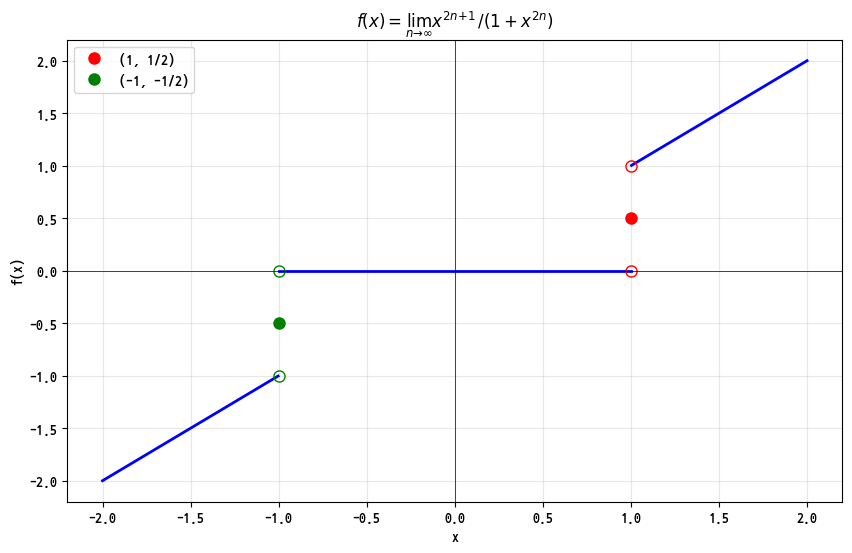

불연속점: x=1, x=-1 (총 2개)
  x=1: 좌극한=0, f(1)=1/2, 우극한=1
  x=-1: 좌극한=-1, f(-1)=-1/2, 우극한=0


In [57]:
# |x| < 1: x^{2n} -> 0 => f(x) = x^{2n+1}/1 -> 0
# |x| > 1: x^{2n} -> inf => f(x) = x^{2n}*x / (x^{2n}(1 + x^{-2n})) = x/1 = x  
# x = 1: 1/2
# x = -1: -1/2

# 큰 n에서 수치적으로 계산
x_vals = np.linspace(-2, 2, 1000)
n_large = 100

# 수치적 문제를 피하기 위해 경우를 나눔
y_vals = np.zeros_like(x_vals)
for i, xi in enumerate(x_vals):
    if abs(xi) < 1 - 1e-10:
        y_vals[i] = 0
    elif abs(xi) > 1 + 1e-10:
        y_vals[i] = xi
    elif abs(xi - 1) < 1e-10:
        y_vals[i] = 0.5
    elif abs(xi + 1) < 1e-10:
        y_vals[i] = -0.5

plt.figure(figsize=(10, 6))
# |x| < 1 부분
mask1 = np.abs(x_vals) < 1
plt.plot(x_vals[mask1], y_vals[mask1], 'b-', linewidth=2)
# |x| > 1 부분  
mask2 = x_vals > 1
mask3 = x_vals < -1
plt.plot(x_vals[mask2], y_vals[mask2], 'b-', linewidth=2)
plt.plot(x_vals[mask3], y_vals[mask3], 'b-', linewidth=2)

# 불연속점 표시
plt.plot(1, 0.5, 'ro', markersize=8, label='(1, 1/2)')
plt.plot(1, 0, 'ro', markersize=8, fillstyle='none')  # 좌극한
plt.plot(1, 1, 'ro', markersize=8, fillstyle='none')  # 우극한
plt.plot(-1, -0.5, 'go', markersize=8, label='(-1, -1/2)')
plt.plot(-1, 0, 'go', markersize=8, fillstyle='none')
plt.plot(-1, -1, 'go', markersize=8, fillstyle='none')

plt.title(r'$f(x) = \lim_{n\to\infty} x^{2n+1}/(1+x^{2n})$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

print("불연속점: x=1, x=-1 (총 2개)")
print("  x=1: 좌극한=0, f(1)=1/2, 우극한=1")
print("  x=-1: 좌극한=-1, f(-1)=-1/2, 우극한=0")

### 과제 6: 로지스틱 손실함수의 미분

$L(y) = \frac{1}{2}(y-t)^2$, $y = \frac{1}{1+e^{-x}}$ (sigmoid)

$\frac{dL}{dx} = ?$

In [58]:
x_sym = sym.Symbol('x')
t_sym = sym.Symbol('t')

# Sigmoid
y = 1 / (1 + sym.exp(-x_sym))

# Loss
L = sym.Rational(1, 2) * (y - t_sym)**2

# dL/dx by chain rule
dL_dx = sym.diff(L, x_sym)
dL_dx_simplified = sym.simplify(dL_dx)

print("y = 1/(1+exp(-x))")
print("L = (1/2)(y-t)^2")
print("\ndL/dx =", dL_dx_simplified)

# 더 명확한 형태: dL/dx = (y-t) * y * (1-y)
# 왜냐하면 dy/dx = y(1-y) (시그모이드의 성질)
dy_dx = sym.diff(y, x_sym)
print("\ndy/dx =", sym.simplify(dy_dx))
print("Note: dy/dx = y(1-y)")
print("Therefore: dL/dx = (y-t) * y(1-y)")

y = 1/(1+exp(-x))
L = (1/2)(y-t)^2

dL/dx = (-t*(exp(x) + 1) + exp(x))*exp(x)/(exp(x) + 1)**3

dy/dx = 1/(4*cosh(x/2)**2)
Note: dy/dx = y(1-y)
Therefore: dL/dx = (y-t) * y(1-y)


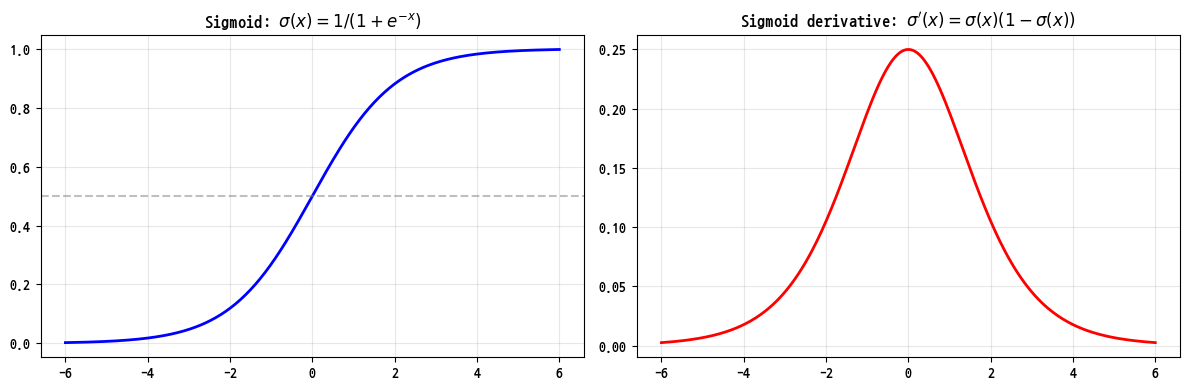

In [59]:
# 시그모이드 함수와 그 도함수 시각화
sigmoid = lambda x: 1 / (1 + np.exp(-x))
sigmoid_deriv = lambda x: sigmoid(x) * (1 - sigmoid(x))

x_vals = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_vals, sigmoid(x_vals), 'b-', linewidth=2)
axes[0].set_title(r'Sigmoid: $\sigma(x) = 1/(1+e^{-x})$')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, sigmoid_deriv(x_vals), 'r-', linewidth=2)
axes[1].set_title(r"Sigmoid derivative: $\sigma'(x) = \sigma(x)(1-\sigma(x))$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 과제 7: 극한값 $\lim_{x \to 1} \frac{x^{100} - 2x + 1}{x - 1}$

In [60]:
x = sym.Symbol('x')
expr = (x**100 - 2*x + 1) / (x - 1)
result = sym.limit(expr, x, 1)
print(f"lim_{{x->1}} (x^100 - 2x + 1)/(x - 1) = {result}")

# 로피탈로 확인: (100x^99 - 2)/1 at x=1 => 100-2 = 98
print(f"L'Hospital: (100*1^99 - 2)/1 = {100*1 - 2}")

lim_{x->1} (x^100 - 2x + 1)/(x - 1) = 98
L'Hospital: (100*1^99 - 2)/1 = 98


### 과제 8: $f(x) = x - |x|$의 연속성과 미분가능성 ($x=0$)

f(0) = 0
lim_{x->0+} f(x) = 0
lim_{x->0-} f(x) = 0
=> f는 x=0에서 연속

x > 0: f(x) = 0 => f'(x) = 0
x < 0: f(x) = 2x => f'(x) = 2
좌미분(2) != 우미분(0) => x=0에서 미분불가능


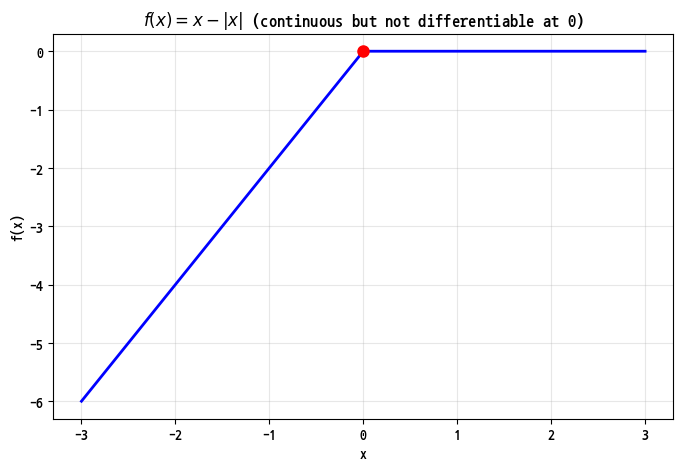

In [61]:
x = sym.Symbol('x')

f = x - sym.Abs(x)

# 연속성 확인
print("f(0) =", f.subs(x, 0))
print("lim_{x->0+} f(x) =", sym.limit(f, x, 0, '+'))  # 0 - 0 = 0
print("lim_{x->0-} f(x) =", sym.limit(f, x, 0, '-'))  # 0 - 0 = 0
print("=> f는 x=0에서 연속")

print()

# 미분가능성: 좌미분, 우미분
# x > 0: f(x) = x - x = 0 => f'(x) = 0
# x < 0: f(x) = x - (-x) = 2x => f'(x) = 2
print("x > 0: f(x) = 0 => f'(x) = 0")
print("x < 0: f(x) = 2x => f'(x) = 2")
print("좌미분(2) != 우미분(0) => x=0에서 미분불가능")

# 시각화
x_vals = np.linspace(-3, 3, 500)
y_vals = x_vals - np.abs(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, 'b-', linewidth=2)
plt.plot(0, 0, 'ro', markersize=8)
plt.title(r'$f(x) = x - |x|$ (continuous but not differentiable at 0)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.show()

### 과제 9: $f(x) = e^{-x^2}$의 그래프와 도함수

In [62]:
x = sym.Symbol('x')

f = sym.exp(-x**2)
f_prime = sym.diff(f, x)
f_double = sym.diff(f, x, 2)

print("f(x)   =", f)
print("f'(x)  =", f_prime)
print("f''(x) =", sym.simplify(f_double))

# 극점, 변곡점
cps = sym.solve(f_prime, x)
print(f"\nCritical points: {cps}")
for cp in cps:
    print(f"  f''({cp}) = {f_double.subs(x, cp)} => {'max' if f_double.subs(x, cp) < 0 else 'min'}")

ips = sym.solve(f_double, x)
print(f"Inflection points: {ips}")

f(x)   = exp(-x**2)
f'(x)  = -2*x*exp(-x**2)
f''(x) = 2*(2*x**2 - 1)*exp(-x**2)

Critical points: [0]
  f''(0) = -2 => max
Inflection points: [-sqrt(2)/2, sqrt(2)/2]


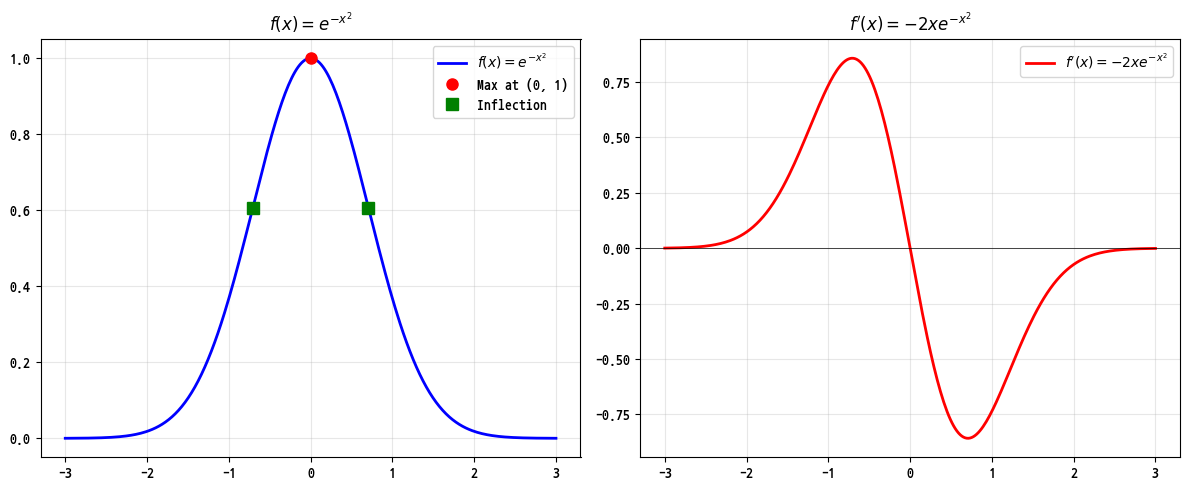

In [63]:
# f(x) = exp(-x^2) 시각화
x_vals = np.linspace(-3, 3, 300)
f_vals = np.exp(-x_vals**2)
fp_vals = -2 * x_vals * np.exp(-x_vals**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_vals, f_vals, 'b-', linewidth=2, label=r'$f(x) = e^{-x^2}$')
axes[0].plot(0, 1, 'ro', markersize=8, label='Max at (0, 1)')
# inflection points at x = ±1/sqrt(2)
ip = 1/np.sqrt(2)
axes[0].plot([ip, -ip], [np.exp(-ip**2), np.exp(-ip**2)], 'gs', markersize=8, label='Inflection')
axes[0].set_title(r'$f(x) = e^{-x^2}$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, fp_vals, 'r-', linewidth=2, label=r"$f'(x) = -2xe^{-x^2}$")
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].set_title(r"$f'(x) = -2xe^{-x^2}$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## VII. 추가 NumPy 기반 미분 실습

### 7.1 수치 미분 함수 (여러 방법 비교)

In [64]:
def forward_diff(f, x, h=1e-7):
    """전방차분"""
    return (f(x + h) - f(x)) / h

def backward_diff(f, x, h=1e-7):
    """후방차분"""
    return (f(x) - f(x - h)) / h

def central_diff(f, x, h=1e-7):
    """중심차분 (가장 정확)"""
    return (f(x + h) - f(x - h)) / (2 * h)

# 비교: f(x) = sin(x) at x=1, exact f'(1) = cos(1)
f = np.sin
x0 = 1.0
exact = np.cos(x0)

print(f"Exact f'(1) = cos(1) = {exact:.15f}\n")

for h in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    fw = forward_diff(f, x0, h)
    bw = backward_diff(f, x0, h)
    ct = central_diff(f, x0, h)
    print(f"h={h:.0e}: forward err={abs(fw-exact):.2e}, "
          f"backward err={abs(bw-exact):.2e}, "
          f"central err={abs(ct-exact):.2e}")

Exact f'(1) = cos(1) = 0.540302305868140

h=1e-02: forward err=4.22e-03, backward err=4.20e-03, central err=9.00e-06
h=1e-04: forward err=4.21e-05, backward err=4.21e-05, central err=9.00e-10
h=1e-06: forward err=4.21e-07, backward err=4.21e-07, central err=2.77e-11
h=1e-08: forward err=2.97e-09, backward err=8.13e-09, central err=2.58e-09
h=1e-10: forward err=5.85e-08, backward err=5.85e-08, central err=5.85e-08


### 7.2 경사하강법 (Gradient Descent) 데모

Final x = 3.000100 (optimal: 3)
Final f(x) = 2.000000 (optimal: 2)


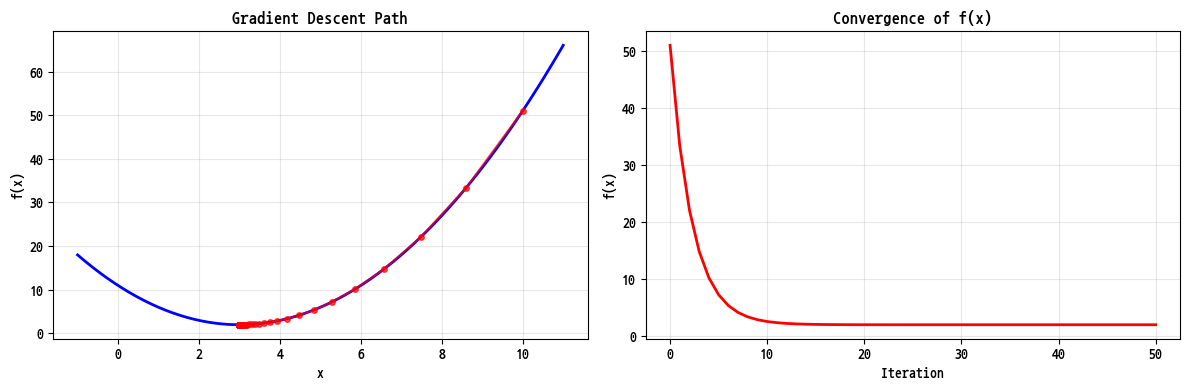

In [65]:
# f(x) = (x-3)^2 + 2 의 최솟값을 경사하강법으로 찾기
f = lambda x: (x - 3)**2 + 2
f_prime = lambda x: 2 * (x - 3)

# 경사하강법
x = 10.0  # 초기값
lr = 0.1  # 학습률
history = [x]

for i in range(50):
    grad = f_prime(x)
    x = x - lr * grad
    history.append(x)

print(f"Final x = {x:.6f} (optimal: 3)")
print(f"Final f(x) = {f(x):.6f} (optimal: 2)")

# 시각화
x_vals = np.linspace(-1, 11, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_vals, f(x_vals), 'b-', linewidth=2)
history_arr = np.array(history)
axes[0].plot(history_arr, f(history_arr), 'ro-', markersize=4, alpha=0.7)
axes[0].set_title('Gradient Descent Path')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(len(history)), f(np.array(history)), 'r-', linewidth=2)
axes[1].set_title('Convergence of f(x)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('f(x)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 2변수 경사하강법

Final (x,y) = (0.000000, 0.000000)
f(x,y) = 0.000000


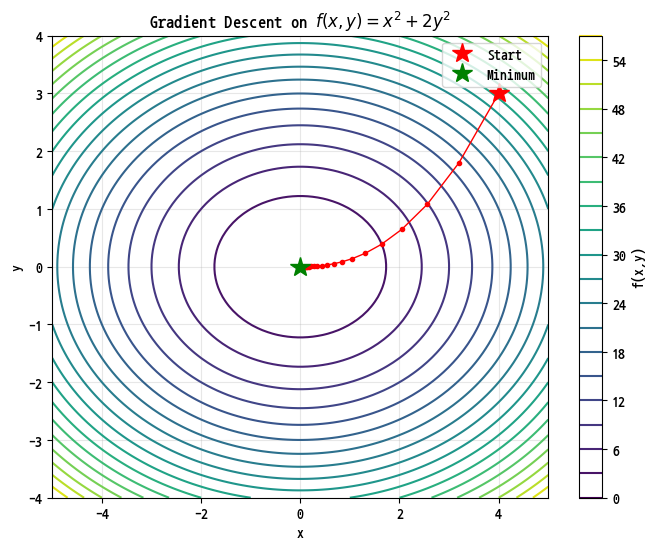

In [66]:
# f(x,y) = x^2 + 2y^2 의 최소점을 찾기
f_2d = lambda xy: xy[0]**2 + 2*xy[1]**2
grad_2d = lambda xy: np.array([2*xy[0], 4*xy[1]])

xy = np.array([4.0, 3.0])
lr = 0.1
history_2d = [xy.copy()]

for i in range(100):
    g = grad_2d(xy)
    xy = xy - lr * g
    history_2d.append(xy.copy())

history_2d = np.array(history_2d)
print(f"Final (x,y) = ({xy[0]:.6f}, {xy[1]:.6f})")
print(f"f(x,y) = {f_2d(xy):.6f}")

# Contour + path
X = np.linspace(-5, 5, 100)
Y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(X, Y)
Z = X**2 + 2*Y**2

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.plot(history_2d[:, 0], history_2d[:, 1], 'ro-', markersize=3, linewidth=1)
plt.plot(history_2d[0, 0], history_2d[0, 1], 'r*', markersize=15, label='Start')
plt.plot(0, 0, 'g*', markersize=15, label='Minimum')
plt.colorbar(label='f(x,y)')
plt.title(r'Gradient Descent on $f(x,y) = x^2 + 2y^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7.4 뉴턴-랩슨 방법 (Newton-Raphson Method)

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

In [67]:
# sqrt(2)를 뉴턴-랩슨으로 구하기: f(x) = x^2 - 2 = 0
f_nr = lambda x: x**2 - 2
fp_nr = lambda x: 2*x

x = 2.0  # 초기값
print(f"{'Iter':>4s} {'x':>20s} {'f(x)':>20s} {'error':>15s}")
print('-' * 65)

for i in range(10):
    print(f"{i:4d} {x:20.15f} {f_nr(x):20.2e} {abs(x - np.sqrt(2)):15.2e}")
    x = x - f_nr(x) / fp_nr(x)

print(f"\nnp.sqrt(2) = {np.sqrt(2):.15f}")

Iter                    x                 f(x)           error
-----------------------------------------------------------------
   0    2.000000000000000             2.00e+00        5.86e-01
   1    1.500000000000000             2.50e-01        8.58e-02
   2    1.416666666666667             6.94e-03        2.45e-03
   3    1.414215686274510             6.01e-06        2.12e-06
   4    1.414213562374690             4.51e-12        1.59e-12
   5    1.414213562373095             4.44e-16        0.00e+00
   6    1.414213562373095            -4.44e-16        2.22e-16
   7    1.414213562373095             4.44e-16        0.00e+00
   8    1.414213562373095            -4.44e-16        2.22e-16
   9    1.414213562373095             4.44e-16        0.00e+00

np.sqrt(2) = 1.414213562373095


---

## Summary

이 노트북에서는 다음을 다루었습니다:

1. **수열과 급수**: 등차/등비수열의 합, 급수의 수렴, 오일러 넘버
2. **함수의 극한과 연속**: 좌극한/우극한, 연속 조건, 중간값 정리
3. **미분**: 도함수, 미분 공식, 연쇄법칙, 고차도함수
4. **테일러 전개**: 함수 근사, 테일러 급수
5. **로피탈의 정리**: 부정형 극한 계산
6. **극대/극소와 볼록성**: 함수 그래프 분석
7. **편미분**: 편도함수, 2차 편미분, 극대/극소 판정
8. **행렬 미분**: 그레디언트, 자코비안, 헤시안
9. **응용**: MLE, 경사하강법, 뉴턴-랩슨법

**주요 파이썬 도구**:
- `numpy`: 수치 계산
- `sympy`: 기호적 미분 (`sym.diff`, `sym.limit`, `sym.series`)
- `matplotlib`: 시각화